# Exercise 7 - The resource-consumer NP model with odeint
**Name:** Tristan Mitchell  
**Student Number:** MTCTRI001 

### AI Declaration
I used ChatGPT to assist with properly formatting my answers and calculations in markdown (LaTeX), without changing the original wording. I also inquired about inserting code into a Markdown cell to reference specific lines when responding to questions. Additionally, I asked for help in writing initial code for some questions, which I then edited and improved. 


In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

The code below represents the dynamics
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
The parameter $k$ is an input to the function

In [3]:
# function that returns the right hand side of the above equations
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [4]:
# initial conditions
K = 0.1
N0 = 5.
P0 = 0.1
state0 = np.array([N0,P0])

# time points (days)
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

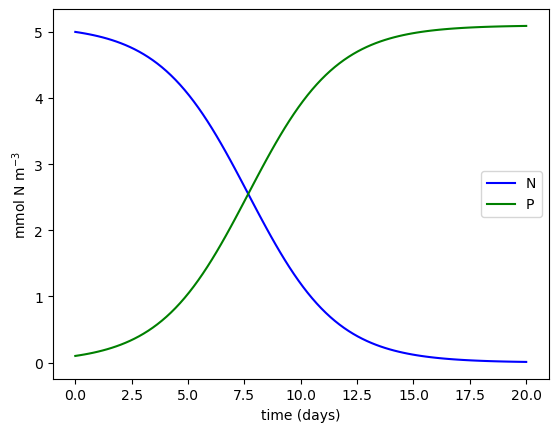

In [5]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()
plt.show()

# Exercise
1. What are the inputs and outputs in the function model? What kind of objects are they?

## Question 1
Looking at the code from above:
```python
def model(state,t,k):

    N,P = state

    Ndot = -k * N * P
    Pdot =  k * N * P

    return np.array([Ndot,Pdot])
```
We can see that the model function takes three inputs (state, t, and k). The state is a NumPy array containing the nutrient concentration (N) and phytoplankton concentration (P). The variable t represents time, and k is the nutrient uptake parameter. The function's output is a NumPy array containing the rates of change of nutrient and phytoplankton concentrations (dN/dt and dP/dt). These outputs are used by odeint to calculate how the concentrations change over time.

2. Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

The model equations can be written using latex. Check the code in the inital cell above. Otherwise you can use the equation editor on Word or LibreOffice.

## Question 2

The new model simulates the nutrient-phytoplankton-detritus (NPD) system, with detritus added as the third state variable. The state variables now include nutrient (N), phytoplankton (P), and detritus (D). Unlike the original NP model, which converts nutrients into phytoplankton biomass without accounting for the mortality rate (m), the NPD model allows some phytoplankton to die and form detritus. The detritus is then decomposed and recycled back into the nutrient pool via remineralization, a process regulated by the rate (r). This becomes a cycle in which phytoplankton grow by consuming nutrients, die and produce detritus, and detritus is remineralized back into the nutrient pool. 

The equations in the new model are:

$$
\frac{dN}{dt}=-kNP+rD
$$

$$
\frac{dP}{dt}=kNP-mP
$$

$$
\frac{dD}{dt}=mP-rD
$$

Where (k) is the nutrient uptake parameter, (m) is the phytoplankton mortality rate, and (r) is the remineralization rate in the new model.

3. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that lead to a realistic solution

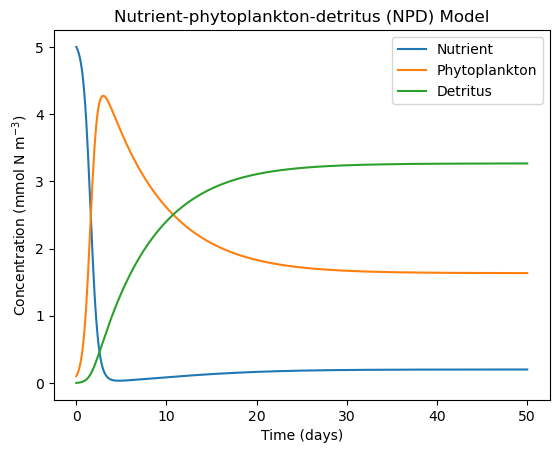

In [11]:
# Question 3
# NPD model
def model_NPD(state, t, k, m, r):
    N, P, D = state # Make the state array from above contain three variables in the model.
    Ndot = -k*N*P + r*D # Nutrients deplete when consumed by phytoplankton and increase through remineralization.
    Pdot = k*N*P - m*P # Phytoplankton population increases through nutrient uptake and decreases through mortality.
    Ddot = m*P - r*D # Detritus increases when phytoplankton die (mortality rate) and decreases through remineralization.

    return np.array([Ndot, Pdot, Ddot]) # Return the rate of change for each of the variables.


# New model parameters using the Gutiérrez-Rodríguez et al. (2011) paper:
k = 0.5 # nutrient uptake 
m = 0.1 # phyto mortality rate
r = 0.05 # remineralization rate

# Initial conditions
N0 = 5.0 # nutrient concentration
P0 = 0.1 # phytoplankton concentration
D0 = 0.0 # detritus concentration

# Store the initial conditions in an array.
state0 = np.array([N0, P0, D0])

# Define the time axis.
t = np.linspace(0, 50, num=500)

# Solve the new NPD model using odeint (remember that args is a tuple)
y = odeint(model_NPD, state0, t, args=(k, m, r))

# Plot the model output
plt.plot(t, y[:,0], label="Nutrient")
plt.plot(t, y[:,1], label="Phytoplankton")
plt.plot(t, y[:,2], label="Detritus")

# Add labels and title
plt.xlabel("Time (days)")
plt.ylabel("Concentration (mmol N m$^{-3}$)")
plt.title("Nutrient-phytoplankton-detritus (NPD) Model")
plt.legend()

# Showing the figure
plt.show()

To select reasonable values for the parameters that lead to a realistic solution, I used values from the Gutiérrez-Rodríguez et al. (2011) paper, which reported phytoplankton growth rates from 0.30 to 1.91 d$^{-1}$ and grazing mortality rates from 0.03 to 1.4 d$^ {-1} $. Based on this, I chose a nutrient uptake rate (k = 0.5) d$^{-1}$ to represent phytoplankton growth and a mortality rate (m = 0.1) d$^{-1}$.

A remineralization rate of r = 0.05 d$^{-1}$ was chosen after googling the global ocean average, which says that a common baseline rate used in biogeochemical models is 0.025 d$^{-1}$ for bulk detritus in the water column.

## Reference
Gutiérrez-Rodríguez, A., Latasa, M., Scharek, R., Massana, R., Vila, G. and Gasol, J.M., 2011. Growth and grazing rate dynamics of major phytoplankton groups in an oligotrophic coastal site. Estuarine, Coastal and Shelf Science, 95(1), pp.77–87. https://doi.org/10.1016/j.ecss.2011.08.008